# Sprint 3: PLN - Clasificación de sentimientos sobre reseñas de películas
Autor: Adrián Robles Arques

El objetivo de este Sprint es realizar una clasificación de sentimientos sobre reseñas de
películas utilizando técnicas de procesamiento de lenguaje natural (PLN). Para ello emplearemos el dataset
movie_reviews de NLTK y usaremos un modelo de Naive Bayes para la clasificación de las reseñas
en categorías positivas y negativas. Por último, vamos a procesar los datos y a evaluar el
modelo utilizando métricas como la precisión y el F1-score.

In [32]:
# Importamos la librería nltk y el dataset
import nltk
import string
from nltk.tokenize import ToktokTokenizer
import re

nltk.download('movie_reviews')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


True

In [33]:
# Importamos el corpus de movie_reviews desde nltk
from nltk.corpus import movie_reviews

# Cargamos el dataset de movie_reviews
reviews = [(movie_reviews.raw(fileid), category) 
            for category in movie_reviews.categories() 
            for fileid in movie_reviews.fileids(category)]

# Verificamos que los datos se cargaron correctamente
print(f"Número total de reseñas: {len(reviews)}")
print(f"Categorías disponibles: {movie_reviews.categories()}")
print(f"Ejemplo de reseña: {reviews[0][1]} - {reviews[0][0][:100]}...")

Número total de reseñas: 2000
Categorías disponibles: ['neg', 'pos']
Ejemplo de reseña: neg - plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
...


In [34]:
# Definimos una función para limpiar el texto
def limpiar_texto(texto):
    
    texto = re.sub(r'\W', ' ', str(texto))
    texto = re.sub(r'\s+[a-zA-Z]\s+', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto, flags=re.I)
    texto = texto.lower()
    
    return texto

In [35]:
# Preprocesamiento de datos
nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words('english'))
reviews_cleaned = []

for review, category in reviews:
    # Limpiamos el texto de la reseña
    review_cleaned = limpiar_texto(review)
    
    # Tokenizamos las palabras
    tokens = ToktokTokenizer().tokenize(review_cleaned)
    
    # Eliminamos las palabras vacías
    tokens = [token for token in tokens if token not in stopwords and len(token) > 1]
    
    reviews_cleaned.append((category, tokens))


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [36]:
print(reviews_cleaned[:5])  # Mostramos las primeras 5 reseñas limpiadas

[('neg', ['plot', 'two', 'teen', 'couples', 'go', 'church', 'party', 'drink', 'drive', 'get', 'accident', 'one', 'guys', 'dies', 'girlfriend', 'continues', 'see', 'life', 'nightmares', 'deal', 'watch', 'movie', 'sorta', 'find', 'critique', 'mind', 'fuck', 'movie', 'teen', 'generation', 'touches', 'cool', 'idea', 'presents', 'bad', 'package', 'makes', 'review', 'even', 'harder', 'one', 'write', 'since', 'generally', 'applaud', 'films', 'attempt', 'break', 'mold', 'mess', 'head', 'lost', 'highway', 'memento', 'good', 'bad', 'ways', 'making', 'types', 'films', 'folks', 'snag', 'one', 'correctly', 'seem', 'taken', 'pretty', 'neat', 'concept', 'executed', 'terribly', 'problems', 'movie', 'well', 'main', 'problem', 'simply', 'jumbled', 'starts', 'normal', 'downshifts', 'fantasy', 'world', 'audience', 'member', 'idea', 'going', 'dreams', 'characters', 'coming', 'back', 'dead', 'others', 'look', 'like', 'dead', 'strange', 'apparitions', 'disappearances', 'looooot', 'chase', 'scenes', 'tons', '

A continuación, con los datos preprocesados, vamos a implementar el modelo de clasificación de sentimientos. Para ello, usaremos el algoritmo Naive Bayes de scikit-learn.

In [37]:
# Importamos las librerias necesarias para el modelo
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score

In [38]:
# Preparar los datos
X = [' '.join(tokens) for _, tokens in reviews_cleaned]
y = [category for category, _ in reviews_cleaned]

# Crear y ajustar el CountVectorizer
vectorizer = CountVectorizer(max_features=5000, min_df=2, max_df=0.8)
X_vectorized = vectorizer.fit_transform(X)

# Transformar las etiquetas a un formato adecuado
y  = np.array([1 if label == 'pos' else -1 for label in y])

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized, y, test_size=0.2, random_state=42, stratify=y
)

# Visualizamos el tamaño de los conjuntos
print(f'Forma de X_train: {X_train.shape}')
print(f'Forma de X_test: {X_test.shape}')
print(f'Vocabulario total: {len(vectorizer.vocabulary_)}')

Forma de X_train: (1600, 5000)
Forma de X_test: (400, 5000)
Vocabulario total: 5000


In [39]:
# Preparamos el modelo Naive Bayes
model = MultinomialNB()

# Entrenamos el modelo
model.fit(X_train, y_train)

# Evaluamos el modelo empleando F1 Score y la precisión

# Inferimos las etiquetas para el conjunto de prueba
y_pred = model.predict(X_test)

# Calculamos la precisión y el F1 Score
accuracy = accuracy_score(y_test, y_pred)
f1_scr = f1_score(y_test, y_pred)

print(f'F1 Score del modelo: {f1_scr:.4f}')
print(f'Precisión del modelo: {accuracy:.4f}')

F1 Score del modelo: 0.8111
Precisión del modelo: 0.8125


Una vez construido y empleado el modelo, vamos a evaluar las palabras más frecuentes entre las reseñas positivas y negativas.

In [47]:
# Separar las reseñas positivas y negativas
positive_reviews = [review for category, review in reviews_cleaned if category == 'pos']
negative_reviews = [review for category, review in reviews_cleaned if category == 'neg']

# Realizamos un conteo de los tokens más frecuentes en las reseñas positivas y negativas
from collections import Counter

# Contamos los tokens en las reseñas positivas
positive_tokens = [token for review in positive_reviews for token in review]
positive_token_counts = Counter(positive_tokens)

# Contamos los tokens en las reseñas negativas
negative_tokens = [token for review in negative_reviews for token in review]
negative_token_counts = Counter(negative_tokens)

# Evaluamos las palabras más comunes en las reseñas positivas y negativas
positive_common = positive_token_counts.most_common(10)
negative_common = negative_token_counts.most_common(10)



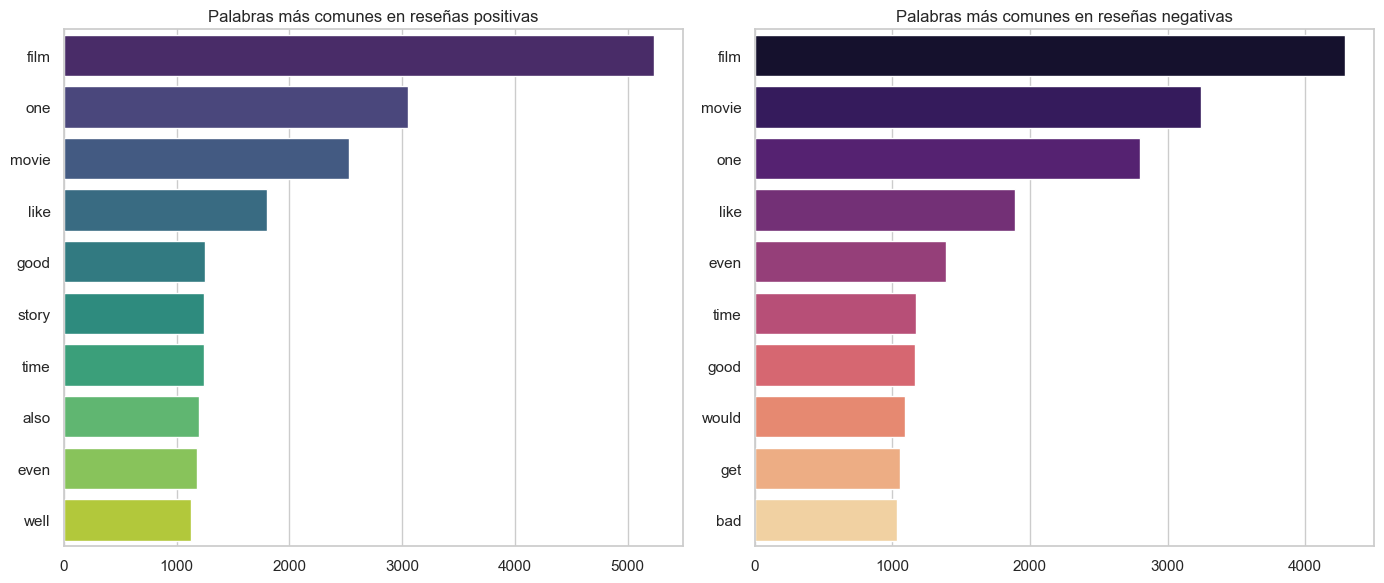

In [53]:
# Generamos un gráfico de barras para visualizar las palabras más comunes
import matplotlib.pyplot as plt
import seaborn as sns

# Extraemos las palabras y sus frecuencias
positive_words, positive_freqs = zip(*positive_common)
negative_words, negative_freqs = zip(*negative_common)

# Configuramos el estilo de los gráficos
sns.set(style="whitegrid")

# Creamos una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Gráfico de palabras positivas
sns.barplot(x=positive_freqs, y=positive_words, hue=positive_words, ax=axes[0], palette='viridis')
axes[0].set_title('Palabras más comunes en reseñas positivas')

# Gráfico de palabras negativas
sns.barplot(x=negative_freqs, y=negative_words, hue=negative_words,ax=axes[1], palette='magma')
axes[1].set_title('Palabras más comunes en reseñas negativas')
plt.tight_layout()
plt.show()